# ultraETH

Analysis notebook.

In [8]:
import pandas as pd
import numpy as np

## Inputs

Set the market inputs below. Values are stored in `inputs` for use in the rest of the notebook.

In [9]:
import ipywidgets as widgets
from IPython.display import display

# --- Input widgets ---
spot_input = widgets.FloatText(
    value=2450.0,  # matches the strikes on the actual quoted structure below
    description="Spot:",
    style={"description_width": "initial"},
)
vol_input = widgets.FloatText(
    value=0.70,   # ETH implied vol assumption (used only for pre-expiry repricing)
    description="Vol:",
    style={"description_width": "initial"},
)

# Live dict of current input values, kept in sync with the widgets.
inputs = {"spot": spot_input.value, "vol": vol_input.value}


def _on_change(change):
    inputs["spot"] = spot_input.value
    inputs["vol"] = vol_input.value


spot_input.observe(_on_change, names="value")
vol_input.observe(_on_change, names="value")

# --- Tab layout ---
market_tab = widgets.VBox([spot_input, vol_input])

input_tabs = widgets.Tab(children=[market_tab])
input_tabs.set_title(0, "Market")

display(input_tabs)

# Payoff

Terminal (expiry) payoff of the whole ultraETH structure, built up in stages: the raw net-of-premium product, then a 10% upfront fee, then a 15% performance fee, and finally the product as offered.

## Whole-product payoff (net of premium)

ultraETH is a premium-financed leveraged call structure, built from actual quoted legs (spot ≈ $2,450) across three expiries:

| Slice | Expiry | Legs |
|---|---|---|
| 1 | 24-Nov-27 | BUY 900x 3062.5-C @ 507.80, SELL 594x 5512.5-C @ 136.22 |
| 2 | 24-Feb-28 | BUY 900x 3062.5-C @ 584.61, SELL 594x 5512.5-C @ 186.85 |
| 3 | 24-Aug-28 | BUY 225x 3062.5-C @ 719.56, BUY 225x 4287.5-C @ 473.43, BUY 225x 5512.5-C @ 342.66 |

Strikes sit at 1.25x / 1.75x / 2.25x spot (25% / 75% / 125% OTM), same shape as before: slices 1-2 are a partial collar (long 25% OTM, short 0.66x 125% OTM), slice 3 is a straight ladder of three long calls. The plotted line is the **USD return net of the premium actually paid** ($1,136,787 total): below breakeven you're at a loss, and if everything expires worthless (< +25%) you lose the full premium (−100%). Breakeven is where the expiry payoff recovers the premium (P&L = 0) — ≈ +48% above spot.

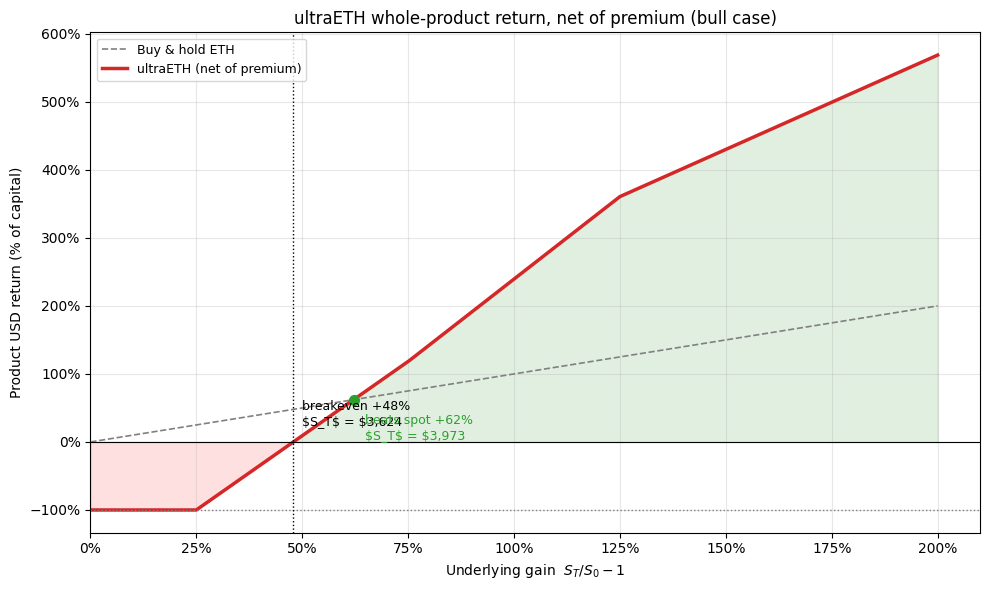

spot = $2,450, total premium = $1,136,787 (actual quotes)
  slice 24Nov27  (T=1.19y, expiry 2027-11-24): net premium $376,105  (33% of structure)
    BUY  900x 3062.5-C @ 507.8
    SELL 594x 5512.5-C @ 136.22
  slice 24Feb28  (T=1.44y, expiry 2028-02-24): net premium $415,160  (37% of structure)
    BUY  900x 3062.5-C @ 584.61
    SELL 594x 5512.5-C @ 186.85
  slice 24Aug28  (T=1.94y, expiry 2028-08-24): net premium $345,521  (30% of structure)
    BUY  225x 3062.5-C @ 719.56
    BUY  225x 4287.5-C @ 473.43
    BUY  225x 5512.5-C @ 342.66
breakeven:   +47.9% above spot   (S_T = $3,624)
beats spot:  +62.2% above spot   (S_T = $3,973)
expiry payoff leverage (slope of product return per 1% underlying):
  25% -> 75%: 4.36x
  75% -> 125%: 4.85x
  125% -> 200%: 2.77x


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import math
from datetime import date
from matplotlib.ticker import PercentFormatter

spot = inputs["spot"]
vol = inputs["vol"]
r = 0.0  # risk-free rate assumption

# Actual quoted legs: (slice label, expiry, strike, qty in ETH (+long/-short), entry premium $/ETH).
trade_rows = [
    ("24Nov27", date(2027, 11, 24), 3062.5,  900.0,  507.80),
    ("24Nov27", date(2027, 11, 24), 5512.5, -594.0,  136.22),
    ("24Feb28", date(2028, 2, 24),  3062.5,  900.0,  584.61),
    ("24Feb28", date(2028, 2, 24),  5512.5, -594.0,  186.85),
    ("24Aug28", date(2028, 8, 24),  3062.5,  225.0,  719.56),
    ("24Aug28", date(2028, 8, 24),  4287.5,  225.0,  473.43),
    ("24Aug28", date(2028, 8, 24),  5512.5,  225.0,  342.66),
]

VAL_DATE = date.today()  # tenor reference for pre-expiry repricing later in the notebook

# Group legs by expiry slice, for display and for the tenor lookup used later.
slices = {}
for name, expiry, K, qty, px in trade_rows:
    slices.setdefault(name, {"expiry": expiry, "T": (expiry - VAL_DATE).days / 365.0, "legs": []})
    slices[name]["legs"].append((qty, K, px))

total_premium = sum(qty * px for _, _, _, qty, px in trade_rows)  # net USD cost of the whole structure
capital = 1.0  # normalized deposit; scale=1.0 means the full deposit buys the structure 1:1 (no wrapper fee)


def _ncdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_call(S, K, sig, T, r=0.0):
    """Black-Scholes call price (used later to reprice legs before expiry)."""
    if T <= 0 or sig <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sig * sig) * T) / (sig * math.sqrt(T))
    d2 = d1 - sig * math.sqrt(T)
    return S * _ncdf(d1) - K * math.exp(-r * T) * _ncdf(d2)


def raw_payoff(S_T, scale=1.0):
    """Terminal intrinsic payoff of the whole structure, as a fraction of capital.

    `scale` is the fraction of capital actually deployed into the structure
    (1.0 = no wrapper fee taken off the deposit before it buys the legs)."""
    S_T = np.asarray(S_T, dtype=float)
    v = np.zeros_like(S_T)
    for _, _, K, qty, _ in trade_rows:
        v += scale * (qty / total_premium) * np.maximum(S_T - K, 0.0)
    return v


def product_value(S_over_spot):
    """Terminal value of the whole product per unit capital, vs S_T/spot."""
    return raw_payoff(np.asarray(S_over_spot, dtype=float) * spot, scale=1.0)


# Bull case grid: 0% to +200% underlying gain.
u = np.linspace(0.0, 2.0, 801)
S_over = 1.0 + u
underlying_ret = u * 100.0                              # buy-and-hold ETH return %
product_ret = (product_value(S_over) - capital) * 100.0  # USD return net of premium %


def _crossings(y):
    """Underlying-return %s where product_ret crosses the array/scalar y."""
    d = product_ret - y
    ab = d > 0
    idx = np.where(ab[:-1] != ab[1:])[0]
    return [underlying_ret[i] + (d[i] / (d[i] - d[i + 1])) *
            (underlying_ret[i + 1] - underlying_ret[i]) for i in idx]


breakevens = _crossings(0.0)             # P&L = 0
beats_spot = _crossings(underlying_ret)  # overtakes buy & hold

fig, ax = plt.subplots(figsize=(10, 6))

# Buy-and-hold ETH reference (45-degree line).
ax.plot(underlying_ret, underlying_ret, color="grey", ls="--", lw=1.2, label="Buy & hold ETH")

# The whole product, net of premium.
ax.plot(underlying_ret, product_ret, "-", color="C3", lw=2.5, label="ultraETH (net of premium)")

# Shade profit (green) vs loss (red).
ax.fill_between(underlying_ret, product_ret, 0, where=product_ret >= 0,
                interpolate=True, color="green", alpha=0.12)
ax.fill_between(underlying_ret, product_ret, 0, where=product_ret < 0,
                interpolate=True, color="red", alpha=0.12)

ax.axhline(0, color="black", lw=0.8)
ax.axhline(-100, color="grey", ls=":", lw=1)  # total-loss floor
ax.set_xlim(left=0)

# Mark breakeven(s) in % and USD.
for ur in breakevens:
    ax.axvline(ur, color="black", ls=":", lw=1)
    ax.annotate(f"breakeven +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, 0), xytext=(6, 12), textcoords="offset points", fontsize=9)

# Mark where the structure overtakes buy & hold.
for ur in beats_spot:
    ax.plot([ur], [ur], "o", color="C2", ms=7)
    ax.annotate(f"beats spot +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, ur), xytext=(8, -28), textcoords="offset points", fontsize=9, color="C2")

ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title("ultraETH whole-product return, net of premium (bull case)")
ax.set_xlabel("Underlying gain  $S_T/S_0 - 1$")
ax.set_ylabel("Product USD return (% of capital)")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Stats ---
print(f"spot = ${spot:,.0f}, total premium = ${total_premium:,.0f} (actual quotes)")
for name, info in slices.items():
    net = sum(qty * px for qty, K, px in info["legs"])
    print(f"  slice {name}  (T={info['T']:.2f}y, expiry {info['expiry']}): "
          f"net premium ${net:,.0f}  ({net / total_premium:.0%} of structure)")
    for qty, K, px in info["legs"]:
        side = "BUY " if qty > 0 else "SELL"
        print(f"    {side} {abs(qty):.0f}x {K}-C @ {px}")
for ur in breakevens:
    print(f"breakeven:   +{ur:.1f}% above spot   (S_T = ${spot * (1 + ur / 100):,.0f})")
for ur in beats_spot:
    print(f"beats spot:  +{ur:.1f}% above spot   (S_T = ${spot * (1 + ur / 100):,.0f})")
print("expiry payoff leverage (slope of product return per 1% underlying):")
for lo, hi in [(25, 75), (75, 125), (125, 200)]:
    lev = (product_value(1 + hi / 100) - product_value(1 + lo / 100)) / ((hi - lo) / 100)
    print(f"  {lo}% -> {hi}%: {lev:.2f}x")

## With a 10% upfront fee

Fork of the payoff above with a **10% upfront fee on deposited capital** — e.g. deposit 10 ETH, 1 ETH is taken as fee and only 9 ETH buys the structure. Returns are still measured against the **full deposit**.

Two reference points are marked:
- **Breakeven** — where the product's USD return recovers to 0 (P&L = 0), net of the fee.
- **Beats spot** — where the product return overtakes simply holding ETH (crosses the buy-and-hold line).

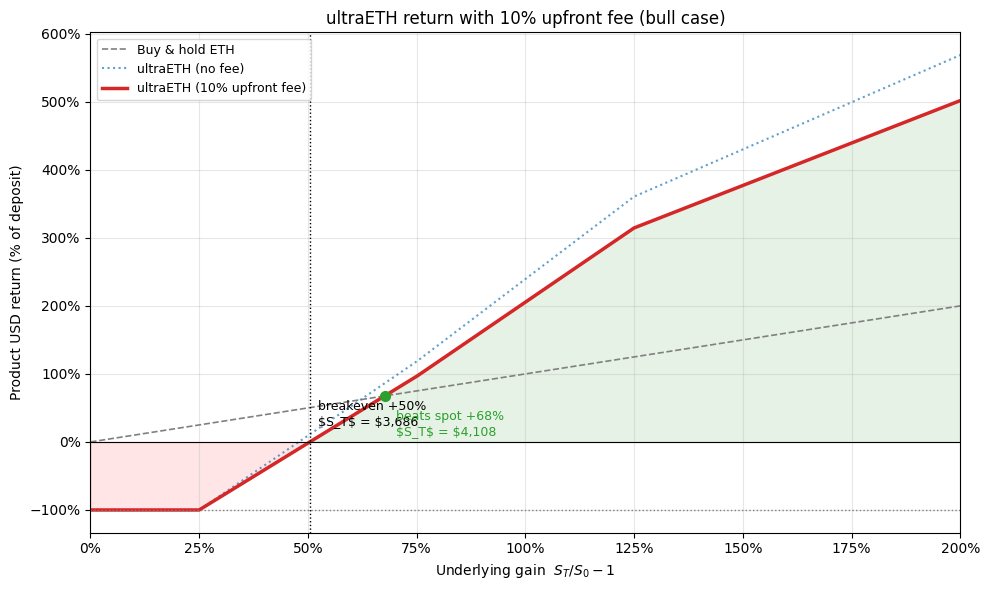

fee = 10%, vol = 70%, r = 0%
breakeven:   +50.5% above spot   (S_T = $3,686)
beats spot:  +67.7% above spot   (S_T = $4,108)
worst case (all worthless): -100% of deposit


In [11]:
%matplotlib inline
# Reuses spot, vol, r, trade_rows, total_premium, raw_payoff(...), product_value(...) from the cell above.

fee = 0.10                       # upfront fee on deposited capital
deployed = capital * (1.0 - fee)  # only this much buys the structure


def product_value_fee(S_over_spot):
    """Terminal value per unit *deposited* capital, after the upfront fee."""
    return raw_payoff(np.asarray(S_over_spot, dtype=float) * spot, scale=deployed)


u = np.linspace(0.0, 2.0, 801)   # cap at +200% underlying gain
S_over = 1.0 + u
underlying_ret = u * 100.0                                   # buy & hold ETH
product_ret_nofee = (product_value(S_over) - capital) * 100.0
product_ret = (product_value_fee(S_over) - capital) * 100.0  # vs full deposit


def crossings(y):
    """Underlying-return %s where product_ret crosses the array/scalar y."""
    d = product_ret - y
    ab = d > 0
    idx = np.where(ab[:-1] != ab[1:])[0]
    out = []
    for i in idx:
        t = d[i] / (d[i] - d[i + 1])
        out.append(underlying_ret[i] + t * (underlying_ret[i + 1] - underlying_ret[i]))
    return out


breakevens = crossings(0.0)               # P&L = 0
beats_spot = crossings(underlying_ret)    # overtakes buy & hold

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(underlying_ret, underlying_ret, color="grey", ls="--", lw=1.2, label="Buy & hold ETH")
ax.plot(underlying_ret, product_ret_nofee, color="C0", ls=":", lw=1.5, alpha=0.7,
        label="ultraETH (no fee)")
ax.plot(underlying_ret, product_ret, "-", color="C3", lw=2.5, label="ultraETH (10% upfront fee)")

ax.fill_between(underlying_ret, product_ret, 0, where=product_ret >= 0,
                interpolate=True, color="green", alpha=0.10)
ax.fill_between(underlying_ret, product_ret, 0, where=product_ret < 0,
                interpolate=True, color="red", alpha=0.10)

ax.axhline(0, color="black", lw=0.8)
ax.axhline(-100, color="grey", ls=":", lw=1)
ax.set_xlim(0, 200)   # cap at +200% underlying gain

for ur in breakevens:
    ax.axvline(ur, color="black", ls=":", lw=1)
    ax.annotate(f"breakeven +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, 0), xytext=(6, 12), textcoords="offset points", fontsize=9)
for ur in beats_spot:
    y = ur  # on the buy & hold line
    ax.plot([ur], [y], "o", color="C2", ms=7)
    ax.annotate(f"beats spot +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, y), xytext=(8, -28), textcoords="offset points", fontsize=9, color="C2")

ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title("ultraETH return with 10% upfront fee (bull case)")
ax.set_xlabel("Underlying gain  $S_T/S_0 - 1$")
ax.set_ylabel("Product USD return (% of deposit)")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Stats ---
print(f"fee = {fee:.0%}, vol = {vol:.0%}, r = {r:.0%}")
for ur in breakevens:
    print(f"breakeven:   +{ur:.1f}% above spot   (S_T = ${spot * (1 + ur / 100):,.0f})")
for ur in beats_spot:
    print(f"beats spot:  +{ur:.1f}% above spot   (S_T = ${spot * (1 + ur / 100):,.0f})")
print(f"worst case (all worthless): {product_ret[0]:.0f}% of deposit")

## Plus a 15% performance fee on profit

Fork of the 10%-upfront-fee version, now also charging a **15% performance fee on profit** — 15% of any terminal value above the original deposit (high-water mark = deposit). The performance fee only applies when the product is in profit, so:
- **Breakeven is unchanged** (≈ +50.5%): at P&L = 0 there is no profit to charge.
- Above breakeven, the investor keeps 85% of gains, so the upside slope flattens and the **beats-spot** point moves further out.

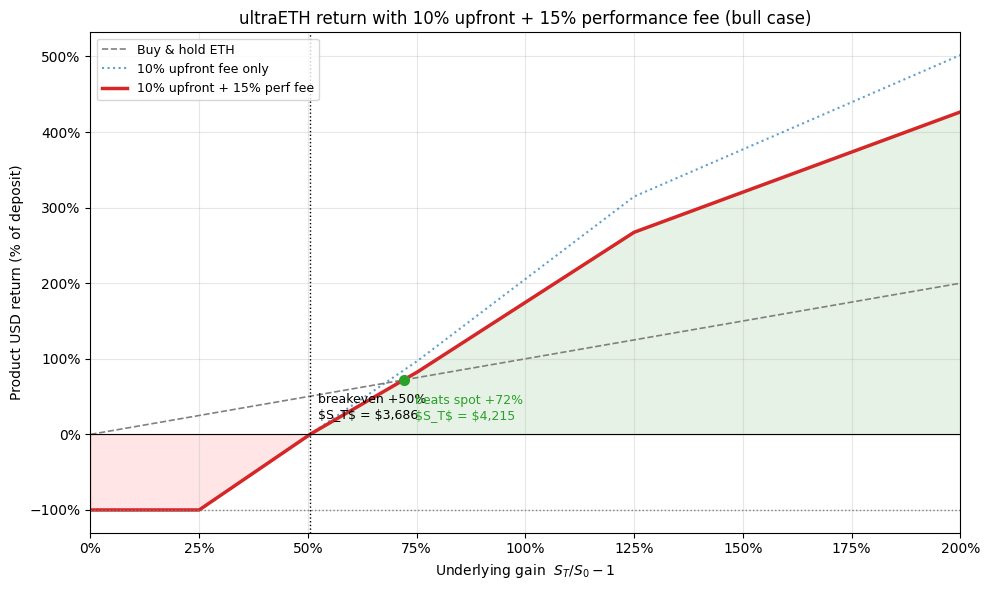

upfront fee = 10%, perf fee = 15%, vol = 70%, r = 0%
breakeven:   +50.5% above spot   (S_T = $3,686)
beats spot:  +72.0% above spot   (S_T = $4,215)
worst case (all worthless): -100% of deposit


In [12]:
%matplotlib inline
# Reuses spot, vol, capital, product_value_fee(...) from the 10%-fee cell above.

perf_fee = 0.15  # performance fee on profit above the deposit (high-water mark)

u = np.linspace(0.0, 2.0, 801)   # bull case, capped at +200%
S_over = 1.0 + u
underlying_ret = u * 100.0

gross_value = product_value_fee(S_over)                        # after 10% upfront fee
profit = np.maximum(gross_value - capital, 0.0)               # vs full deposit
net_value = gross_value - perf_fee * profit                  # minus 15% perf fee
product_ret = (net_value - capital) * 100.0                  # USD return vs deposit
product_ret_upfront_only = (gross_value - capital) * 100.0   # 10% fee, no perf fee


def crossings(y):
    d = product_ret - y
    ab = d > 0
    idx = np.where(ab[:-1] != ab[1:])[0]
    return [underlying_ret[i] + (d[i] / (d[i] - d[i + 1])) *
            (underlying_ret[i + 1] - underlying_ret[i]) for i in idx]


breakevens = crossings(0.0)
beats_spot = crossings(underlying_ret)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(underlying_ret, underlying_ret, color="grey", ls="--", lw=1.2, label="Buy & hold ETH")
ax.plot(underlying_ret, product_ret_upfront_only, color="C0", ls=":", lw=1.5, alpha=0.7,
        label="10% upfront fee only")
ax.plot(underlying_ret, product_ret, "-", color="C3", lw=2.5,
        label="10% upfront + 15% perf fee")

ax.fill_between(underlying_ret, product_ret, 0, where=product_ret >= 0,
                interpolate=True, color="green", alpha=0.10)
ax.fill_between(underlying_ret, product_ret, 0, where=product_ret < 0,
                interpolate=True, color="red", alpha=0.10)

ax.axhline(0, color="black", lw=0.8)
ax.axhline(-100, color="grey", ls=":", lw=1)
ax.set_xlim(0, 200)

for ur in breakevens:
    ax.axvline(ur, color="black", ls=":", lw=1)
    ax.annotate(f"breakeven +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, 0), xytext=(6, 12), textcoords="offset points", fontsize=9)
for ur in beats_spot:
    ax.plot([ur], [ur], "o", color="C2", ms=7)
    ax.annotate(f"beats spot +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, ur), xytext=(8, -28), textcoords="offset points", fontsize=9, color="C2")

ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title("ultraETH return with 10% upfront + 15% performance fee (bull case)")
ax.set_xlabel("Underlying gain  $S_T/S_0 - 1$")
ax.set_ylabel("Product USD return (% of deposit)")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Stats ---
print(f"upfront fee = {fee:.0%}, perf fee = {perf_fee:.0%}, vol = {vol:.0%}, r = {r:.0%}")
for ur in breakevens:
    print(f"breakeven:   +{ur:.1f}% above spot   (S_T = ${spot * (1 + ur / 100):,.0f})")
for ur in beats_spot:
    print(f"beats spot:  +{ur:.1f}% above spot   (S_T = ${spot * (1 + ur / 100):,.0f})")
print(f"worst case (all worthless): {product_ret[0]:.0f}% of deposit")

## ultraETH — final payoff

The product as offered (10% upfront + 15% performance fee), versus simply holding ETH.

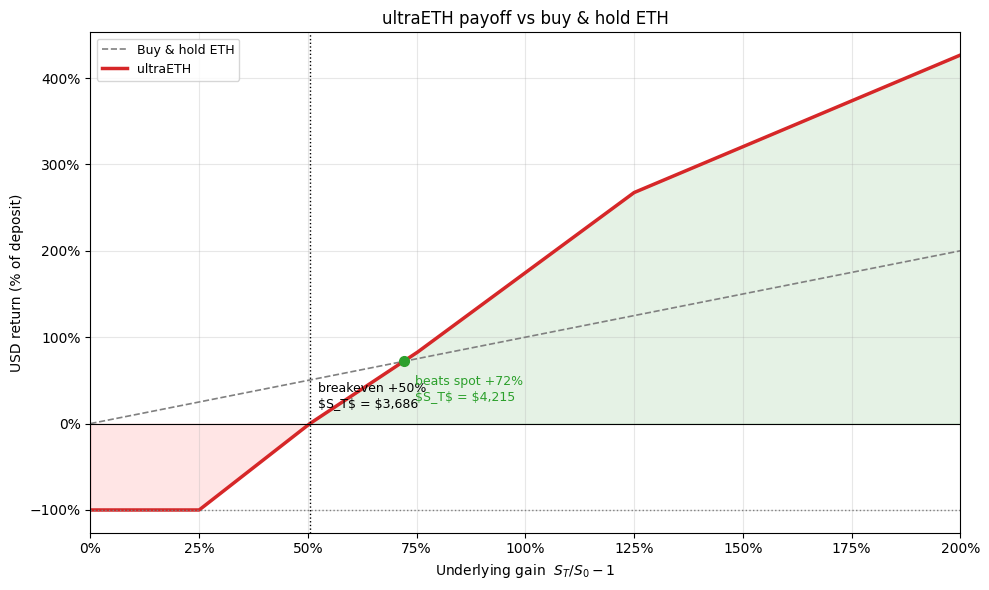

In [13]:
%matplotlib inline
# Reuses spot, vol, capital, fee, perf_fee, product_value_fee(...) from cells above.

u = np.linspace(0.0, 2.0, 801)   # bull case, capped at +200%
S_over = 1.0 + u
underlying_ret = u * 100.0

gross_value = product_value_fee(S_over)                     # after 10% upfront fee
net_value = gross_value - perf_fee * np.maximum(gross_value - capital, 0.0)
product_ret = (net_value - capital) * 100.0                 # ultraETH USD return vs deposit


def crossings(y):
    d = product_ret - y
    ab = d > 0
    idx = np.where(ab[:-1] != ab[1:])[0]
    return [underlying_ret[i] + (d[i] / (d[i] - d[i + 1])) *
            (underlying_ret[i + 1] - underlying_ret[i]) for i in idx]


breakevens = crossings(0.0)
beats_spot = crossings(underlying_ret)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(underlying_ret, underlying_ret, color="grey", ls="--", lw=1.2, label="Buy & hold ETH")
ax.plot(underlying_ret, product_ret, "-", color="C3", lw=2.5, label="ultraETH")

ax.fill_between(underlying_ret, product_ret, 0, where=product_ret >= 0,
                interpolate=True, color="green", alpha=0.10)
ax.fill_between(underlying_ret, product_ret, 0, where=product_ret < 0,
                interpolate=True, color="red", alpha=0.10)

ax.axhline(0, color="black", lw=0.8)
ax.axhline(-100, color="grey", ls=":", lw=1)
ax.set_xlim(0, 200)

for ur in breakevens:
    ax.axvline(ur, color="black", ls=":", lw=1)
    ax.annotate(f"breakeven +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, 0), xytext=(6, 12), textcoords="offset points", fontsize=9)
for ur in beats_spot:
    ax.plot([ur], [ur], "o", color="C2", ms=7)
    ax.annotate(f"beats spot +{ur:.0f}%\n$S_T$ = ${spot * (1 + ur / 100):,.0f}",
                xy=(ur, ur), xytext=(8, -28), textcoords="offset points", fontsize=9, color="C2")

ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title("ultraETH payoff vs buy & hold ETH")
ax.set_xlabel("Underlying gain  $S_T/S_0 - 1$")
ax.set_ylabel("USD return (% of deposit)")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Instantaneous value

How much your position is worth **today** if spot moved to +x% immediately, with the full tenor still remaining (time value intact), priced at 70% vol and net of the upfront fee. Values are shown as a % of the original deposit, alongside simply holding ETH.

The step-up between rows is the **instantaneous delta** (≈ 1.9× at spot — the position moves ~1.9% for a 1% move in ETH today).

In [14]:
# How much is your position worth if spot moves to +x% immediately (full tenor, 70% vol),
# net of the upfront fee. Uses trade_rows, slices, total_premium, bs_call, deployed from the Payoff section.


def mtm_value(x_over_spot):
    """Value now, per unit deposit, if spot -> x*spot immediately (full tenor remaining)."""
    x = np.atleast_1d(np.asarray(x_over_spot, dtype=float)) * spot
    v = np.zeros_like(x)
    for name, expiry, K, qty, px in trade_rows:
        T = slices[name]["T"]
        v += deployed * (qty / total_premium) * np.array([bs_call(s, K, vol, T, r) for s in x])
    return v


moves = [0, 10, 25, 50, 75, 100, 125, 150]  # immediate underlying move, %
rows = []
for mv in moves:
    ue = float(mtm_value(1 + mv / 100)[0]) * 100.0   # ultraETH value now, % of deposit
    eth = 100.0 + mv                                  # hold ETH value, % of deposit
    rows.append({
        "Immediate move": f"+{mv}%",
        "ultraETH": f"{ue:.0f}%",
        "Hold ETH": f"{eth:.0f}%",
        "vs Hold ETH": f"{ue - eth:+.0f}pp",
    })

worth_table = pd.DataFrame(rows).set_index("Immediate move")
worth_table

,ultraETH,Hold ETH,vs Hold ETH
Immediate move,,,
+0%,91%,100%,-9pp
+10%,111%,110%,+1pp
+25%,142%,125%,+17pp
+50%,199%,150%,+49pp
+75%,259%,175%,+84pp
+100%,321%,200%,+121pp
+125%,384%,225%,+159pp
+150%,448%,250%,+198pp
